In [2]:
from tripodpy import Simulation

In [3]:
sim = Simulation()

Podemos revisar las condiciones iniciales. Todo en CGS units

In [11]:
sim.ini

namespace(dust=namespace(aIniMax=0.0001,
                         allowDriftingParticles=False,
                         d2gRatio=0.01,
                         distExp=-3.5,
                         rhoMonomer=1.67,
                         vFrag=100.0),
          gas=namespace(alpha=0.001,
                        Mdisk=9.942049353490256e+31,
                        mu=3.847030424486999e-24,
                        SigmaExp=-1.0,
                        SigmaRc=897587224200000.0),
          grid=namespace(mmin=1e-12,
                         Nr=100,
                         rmin=14959787070000.0,
                         rmax=1.495978707e+16),
          star=namespace(M=1.988409870698051e+33, R=139140000000.0, T=5772.0))

Las condiciones iniciales de los parametrso de la estrella tiene influencia en el timescale de la simulacion y del perfil de temperatura

La masa tiene rol en el timescale, debido a la gravedad yo creo
El radio tiene influencia en el perfil de temperatura
obvimante la temperatura igual itnee influencia en el perfil de temperatura

**M** = Stellar Mass

**R** = Stellar Radius

**T** = Temperature

In [18]:
sim.ini.star

namespace(M=1.988409870698051e+33, R=139140000000.0, T=5772.0)

Las condiciones iniciales del grid determina la forma del grid radial.

**mmin** = Masa minima de las particulas

**Nr** = Numero del celdas en la direccion radial

**rmin** = Ubicacion de la celda mas cercana (Default 1 UA)

**rmax** = Ubicaicon de la celda mas lejana (default 1000 UA)


In [19]:
sim.ini.grid

namespace(mmin=1e-12, Nr=100, rmin=14959787070000.0, rmax=1.495978707e+16)

Condiciones iniciales del gas del disco. El perfil de densidad superficial estandar es solucion similar de [Lynden-Bell & Pringle (1974).](https://doi.org/10.1093/mnras/168.3.603)

**alpha ($\alpha$)** = Alpha viscosity parameter, def $10^{-3}$ [Shakura & Sunyaev (1973)](http://adsabs.harvard.edu/abs/1973A%26A....24..337S)

**Mdisk** = Masa inicial del gas en el disco 

**mu ($\mu$)** = Peso molecuar promedio , def 2.3 $m_{proton}$

**SigmaExp ($\Sigma_{exp}$)** = Power law exponent of surface density profile, default -1 [Lynden-Bell & Pringle (1974)](https://doi.org/10.1093/mnras/168.3.603)

**SigmaRc ($\Sigma_{Rc}$)** = critical cut off (distancia a la que el disco deja de comportante como ley de potencia y decae exponencialmente) [Lynden-Bell & Pringle (1974)](https://doi.org/10.1093/mnras/168.3.603)

In [20]:
sim.ini.gas

namespace(alpha=0.001,
          Mdisk=9.942049353490256e+31,
          mu=3.847030424486999e-24,
          SigmaExp=-1.0,
          SigmaRc=897587224200000.0)

Condiciones iniciales del polvo del disco y tambien el comportamiento de las colisiones.


**aIniMax ($s_{max}$)** = tamaño maximo de las particulas, default 1 $\mu m$

**allowDriftingParticles** = Flag que recorta la distribución de polvo en el disco externo si el tamaño inicial de las partículas supera el límite de drift.
Evita la aparición de ondas espurias (no físicas) durante las etapas iniciales de la simulación al eliminar condiciones iniciales inconsistentes. (BOOLEANO)

**d2gRatio** = Ratio dust to gas inicial, default ($10^{-2}$)

**distExp** = Controla la distribución inicial de tamaños de particulas de polvo. Define como se reparte la cantidad de partculas segun su tamaño seguiendo una ley de potencias hasta un tamaño maximo de $a_{max}$ (generalmente $a$ define el tamaño de la particula). Valor por defecto -3.5, si distExp = -4: Dominado por polvo pequeño, si distExp = -2.5: más particulas grandes.

**rhoMonomer** = Densidad volumetrica del material solido que compone las particulas de polvo ("Densidad interna del grano"), valor por defecto 1.67 $g/cm^3$. Afecta acoplamiento gas-polvo, masa de cada particula, velocidad del drift

**vfrag** = Velocidad de fragmentacion. Default 1 m/s. Particulas que colisionan a una velocidad mayor a 1 m/s se fragmentan. 

In [ ]:
sim.ini.dust



namespace(aIniMax=0.0001,
          allowDriftingParticles=False,
          d2gRatio=0.01,
          distExp=-3.5,
          rhoMonomer=1.67,
          vFrag=100.0)

In [ ]:
from dustpy import constants as c
# Estas constantes ya estan en csg :D

print(c.M_sun)

1.988409870698051e+33


In [26]:
sim.ini.gas.Mdisk = 0.1 * c.M_sun

In [27]:
sim.ini.gas

namespace(alpha=0.001,
          Mdisk=1.988409870698051e+32,
          mu=3.847030424486999e-24,
          SigmaExp=-1.0,
          SigmaRc=897587224200000.0)

In [28]:
sim.initialize()


In [29]:
import numpy as np
# Genera 6 numeros, en log base 10, con exponentes entre 3 y 4 x-espaciados.
# Entonces es algo asi como 10**3 , 10**3.2, ... , 10**4, luego lo pasamos a años en unidades cgs
sim.t.snapshots = np.logspace(3, 4, num=6, base=10) * c.year

## Como cambiar nombre del directorio creado

Esto es muy importante si queremos gestionar los outputs de nuestras simulaciones

Tenemos 2 opciones:

1. Habilitar la sobreescritura de los archivos ya existentes con el mismo directorio: Simulation.writer.overwrite = True / False
2. Cambiar el directorio/path del output: sim.writer.datadir = "2_data"

In [30]:
sim.writer.datadir = "2_data"


In [31]:
sim.run()


tripodpy v1.0.0

Creating data directory 2_data.
Writing file 2_data\data0000.hdf5
Writing dump file 2_data\frame.dmp
Writing file 2_data\data0001.hdf5
Writing dump file 2_data\frame.dmp
Writing file 2_data\data0002.hdf5
Writing dump file 2_data\frame.dmp
Writing file 2_data\data0003.hdf5
Writing dump file 2_data\frame.dmp
Writing file 2_data\data0004.hdf5
Writing dump file 2_data\frame.dmp
Writing file 2_data\data0005.hdf5
Writing dump file 2_data\frame.dmp
Execution time: 0:00:04


In [ ]:
sim.t / c.year # Convertimos a años para revisar por cuanto tiempo corrimos nuestra simulacion

10000.0

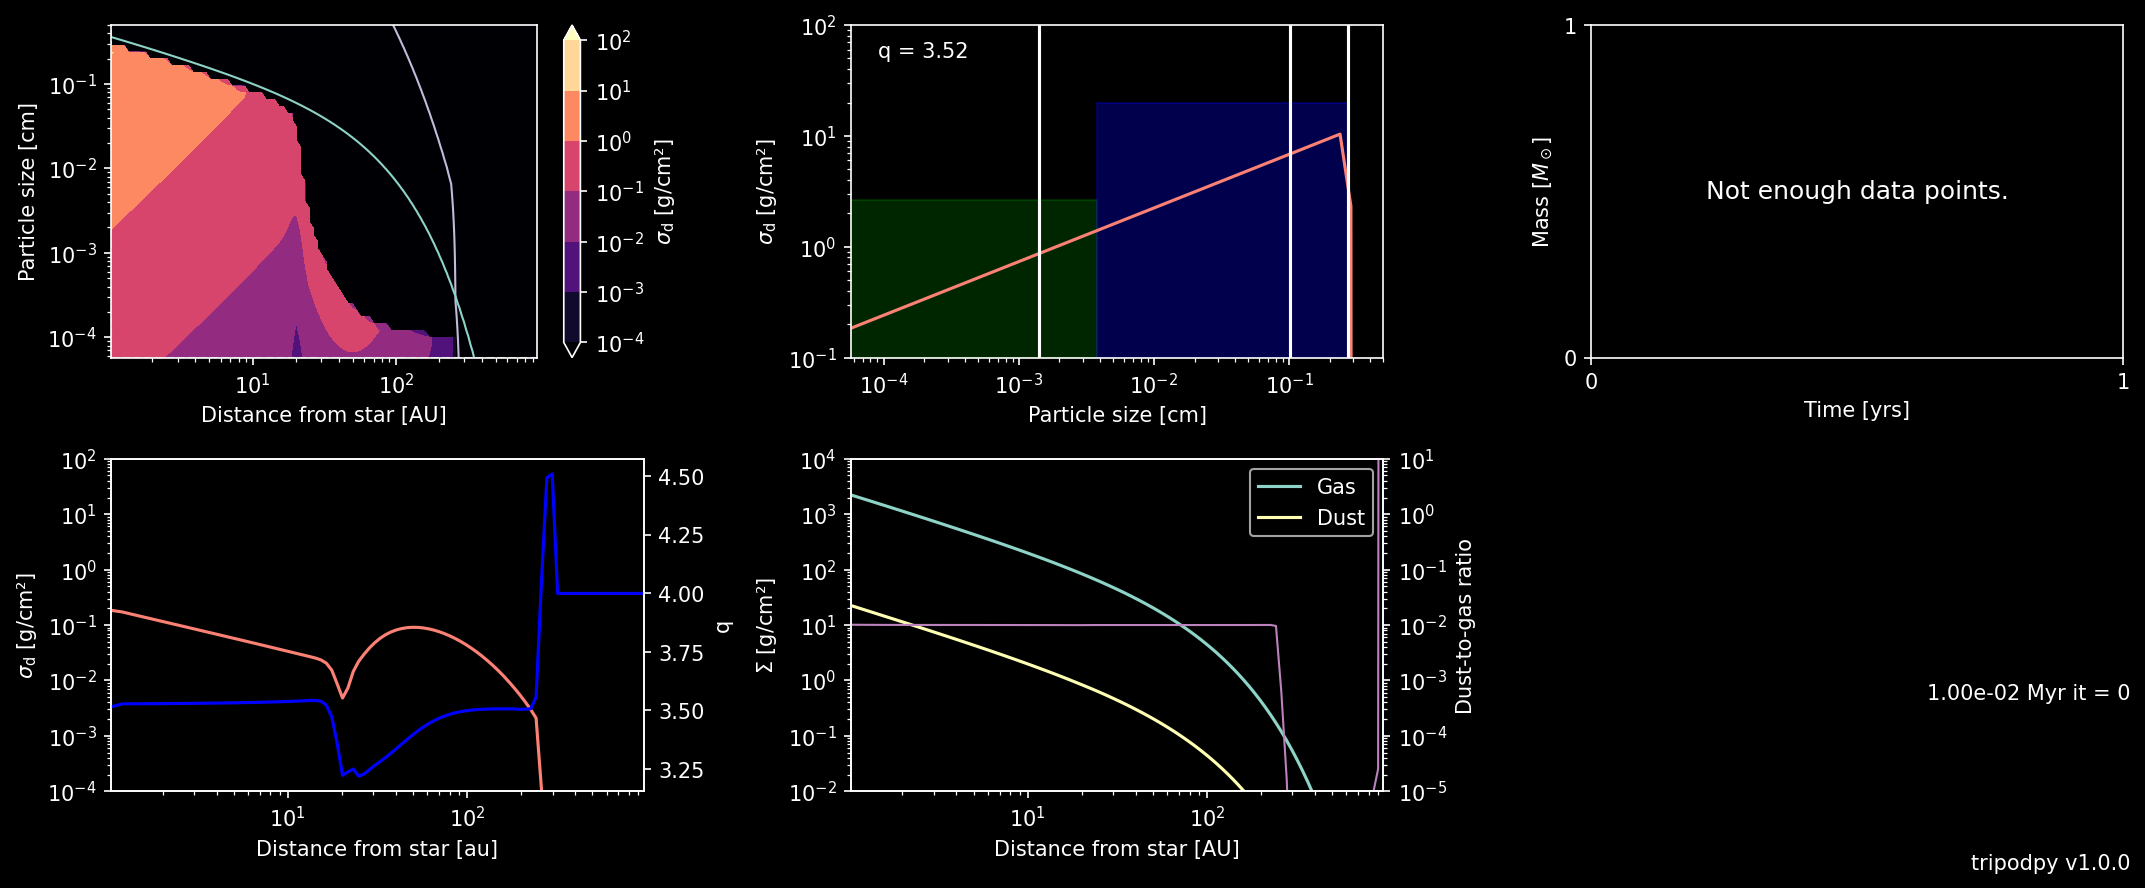

In [ ]:
from tripodpy import plot

plot.panel(sim)
    